In [1]:
# %%
"""
📌 Notebook: 06_gru_model.ipynb

🎯 Purpose:
Train an optimized GRU model for driving behavior classification.

🔥 Improvements:
- Correct label encoding (0–4)
- Deeper GRU architecture
- BatchNormalization + Dropout
- EarlyStopping + ModelCheckpoint
- Learning rate scheduling
- Class balancing
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.utils.class_weight import compute_class_weight

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [2]:
# %%
# GPU Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU ready for GRU.")
    except RuntimeError as e:
        print(e)

✅ GPU ready for GRU.


In [3]:
# %%
# Create folders safely
folders = [
    "../models",
    "../results/graphs",
    "../results/confusion_matrix"
]

for folder in folders:
    if os.path.isfile(folder):
        os.remove(folder)
    os.makedirs(folder, exist_ok=True)

In [4]:
# %%
# Load data
X_train = np.load("../processed_data/X_train.npy")
y_train = np.load("../processed_data/y_train.npy")
X_test = np.load("../processed_data/X_test.npy")
y_test = np.load("../processed_data/y_test.npy")

# ✅ FIX LABELS
y_train = y_train - 1
y_test = y_test - 1

print("✅ Data loaded.")
print(f"Shape: {X_train.shape}")

✅ Data loaded.
Shape: (109326, 100, 9)


In [5]:
# %%
"""
🔹 Class Weights (Handle imbalance)
"""

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("✅ Class weights:", class_weights)

✅ Class weights: {0: 1.1070987341772152, 1: 1.2029709507042254, 2: 0.8370415741520557, 3: 0.7594192831342039, 4: 1.3262889724614824}


In [6]:
# %%
"""
🔹 GRU Model Architecture
"""

model = models.Sequential([
    
    layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.GRU(64, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.GRU(32),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 100, 128)          53376     
                                                                 
 batch_normalization (BatchN  (None, 100, 128)         512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 100, 128)          0         
                                                                 
 gru_1 (GRU)                 (None, 100, 64)           37248     
                                                                 
 batch_normalization_1 (Batc  (None, 100, 64)          256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 100, 64)           0

In [7]:
# %%
"""
🔹 Callbacks (VERY IMPORTANT)
"""

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "../models/best_gru_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

# 🔥 Learning rate scheduler
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

In [8]:
# %%
"""
🔹 Training (OPTIMIZED)
"""

history = model.fit(
    X_train, y_train,
    epochs=70,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weights,
    verbose=1
)

# Save history
with open('../results/gru_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("✅ GRU training complete.")

Epoch 1/70
1538/1538 [==============================] - 129s 73ms/step - loss: 1.1648 - accuracy: 0.4956 - val_loss: 1.1157 - val_accuracy: 0.6004 - lr: 0.0010
Epoch 2/70
1538/1538 [==============================] - 87s 57ms/step - loss: 0.7306 - accuracy: 0.7034 - val_loss: 0.5668 - val_accuracy: 0.7670 - lr: 0.0010
Epoch 3/70
1538/1538 [==============================] - 86s 56ms/step - loss: 0.5790 - accuracy: 0.7663 - val_loss: 0.4873 - val_accuracy: 0.8096 - lr: 0.0010
Epoch 4/70
1538/1538 [==============================] - 88s 57ms/step - loss: 0.5163 - accuracy: 0.7933 - val_loss: 0.4272 - val_accuracy: 0.8248 - lr: 0.0010
Epoch 5/70
1538/1538 [==============================] - 88s 57ms/step - loss: 0.4665 - accuracy: 0.8117 - val_loss: 0.4177 - val_accuracy: 0.8324 - lr: 0.0010
Epoch 6/70
1538/1538 [==============================] - 90s 59ms/step - loss: 0.4286 - accuracy: 0.8269 - val_loss: 0.3747 - val_accuracy: 0.8480 - lr: 0.0010
Epoch 7/70
1538/1538 [=======================

In [9]:
# %%
"""
💾 Save Final Model
"""

model.save("../models/gru_model.h5")
print("✅ GRU model saved.")

✅ GRU model saved.


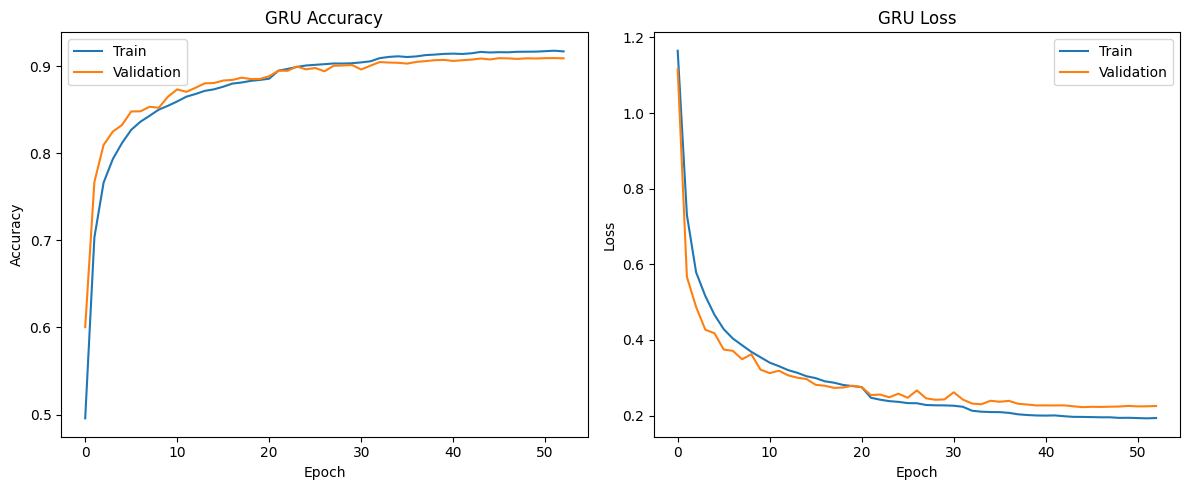

✅ Graph saved.


In [10]:
# %%
"""
📊 Plot Performance
"""

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../results/graphs/gru_performance_curves.png')
plt.show()

print("✅ Graph saved.")